In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.stats import t
from scipy.stats import jarque_bera

df = pd.read_excel("OLS_and_ML_40.xlsx")

df

,Y,X1
0,31.847416,8.520947
1,10.728718,5.569246
2,23.295895,7.374137
3,31.469251,7.977606
4,33.547873,8.693558
...,...,...
1495,3.204838,4.698854
1496,14.752273,6.849772
1497,22.328102,7.452918
1498,0.330768,1.525998


In [2]:
X = sm.add_constant(df['X1'])
y = df['Y']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     3572.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        20:04:03   Log-Likelihood:                -5219.3
No. Observations:                1500   AIC:                         1.044e+04
Df Residuals:                    1498   BIC:                         1.045e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.5145      0.415    -15.695      0.000      -7.329      -5.700
X1             4.1792      0.070     59.766      0.000       4.042       4.316
==============================================================================
Omnibus:                      154.736   Durbin-Watson:                   2.131
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              108.685
Skew:                           0.550   Prob(JB):                     2.51e-24
Kurtosis:                       2.273   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

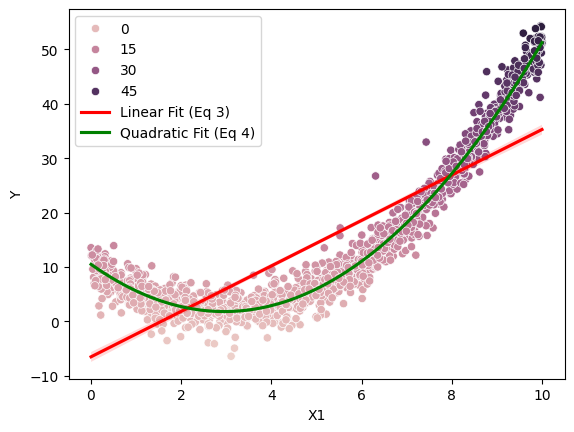

In [4]:
import os

# Scatterplot
ax = sns.scatterplot(data=df, x="X1", y="Y", hue="Y")
## linear fit, eq3
sns.regplot(
    data=df, x="X1", y="Y",
    scatter=False, ax=ax, color="red", label="Linear Fit (Eq 3)"
)
## quadratic fit, eq4
sns.regplot(
    data=df, x="X1", y="Y",
    scatter=False, ax=ax, color="green", order=2, label="Quadratic Fit (Eq 4)"
)

plt.legend()

output_dir = "images"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(os.path.join(output_dir, "linear_vs_quadratic_fit.png"), dpi=300, bbox_inches="tight")
plt.show()

# 2.i Ramsey RESET 1

In [5]:
y_hat = model.fittedvalues

y_hat.head()

X_reset = pd.DataFrame({
    'const': 1,
    'X1': df['X1'],
    'yhat_sq': y_hat**2
})

reset_model = sm.OLS(y, X_reset).fit()

reset_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 2.873e+04
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        20:08:00   Log-Likelihood:                -3378.6
No. Observations:                1500   AIC:                             6763.
Df Residuals:                    1497   BIC:                             6779.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1035      0.168     48.230      0.000       7.774       8.433
X1            -2.7840      0.059    -47.295      0.000      -2.899      -2.669
yhat_sq        0.0571      0.000    126.196      0.000       0.056       0.058
==============================================================================
Omnibus:                       72.525   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              226.601
Skew:                           0.132   Prob(JB):                     6.23e-50
Kurtosis:                       4.886   Cond. No.                     1.57e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.57e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:
t_stat = reset_model.tvalues['yhat_sq']
p_value = reset_model.pvalues['yhat_sq']

print("Ramsey RESET test result:")
print(f"t-statistic = {t_stat}")
print(f"p-value = {p_value}")

Ramsey RESET test result:
t-statistic = 126.19578088499851
p-value = 0.0


# 2.j Ramsey RESET 2

In [7]:
df['X1_sq'] = df['X1']**2

X_quad = sm.add_constant(df[['X1', 'X1_sq']])
y = df['Y']

model_quad = sm.OLS(y, X_quad).fit()
model_quad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 2.873e+04
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        20:08:04   Log-Likelihood:                -3378.6
No. Observations:                1500   AIC:                             6763.
Df Residuals:                    1497   BIC:                             6779.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5248      0.182     57.899      0.000      10.168      10.881
X1            -5.8906      0.082    -71.499      0.000      -6.052      -5.729
X1_sq          0.9965      0.008    126.196      0.000       0.981       1.012
==============================================================================
Omnibus:                       72.525   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              226.601
Skew:                           0.132   Prob(JB):                     6.23e-50
Kurtosis:                       4.886   Cond. No.                         154.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
y_hat_quad = model_quad.fittedvalues

X_reset_quad = pd.DataFrame({
    'const': 1,
    'X1': df['X1'],
    'X1_sq': df['X1_sq'],
    'yhat_sq': y_hat_quad**2
})

reset_model_quad = sm.OLS(y, X_reset_quad).fit()
reset_model_quad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 1.916e+04
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        20:08:07   Log-Likelihood:                -3378.1
No. Observations:                1500   AIC:                             6764.
Df Residuals:                    1496   BIC:                             6785.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3799      0.229     45.266      0.000       9.930      10.830
X1            -5.7642      0.147    -39.166      0.000      -6.053      -5.476
X1_sq          0.9775      0.020     48.944      0.000       0.938       1.017
yhat_sq        0.0004      0.000      1.036      0.300      -0.000       0.001
==============================================================================
Omnibus:                       73.747   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              233.504
Skew:                           0.133   Prob(JB):                     1.97e-51
Kurtosis:                       4.915   Cond. No.                     3.56e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.56e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [9]:
t_stat = reset_model_quad.tvalues['yhat_sq']
p_value = reset_model_quad.pvalues['yhat_sq']

print("RESET test (quadratic model):")
print(f"t-statistic = {t_stat}")
print(f"p-value = {p_value}")

RESET test (quadratic model):
t-statistic = 1.0361679543776252
p-value = 0.3002912497128069


# 2.k JB test

Jarque-Bera test:
JB statistic = 226.6005217615219
p-value = 6.227617083002518e-50


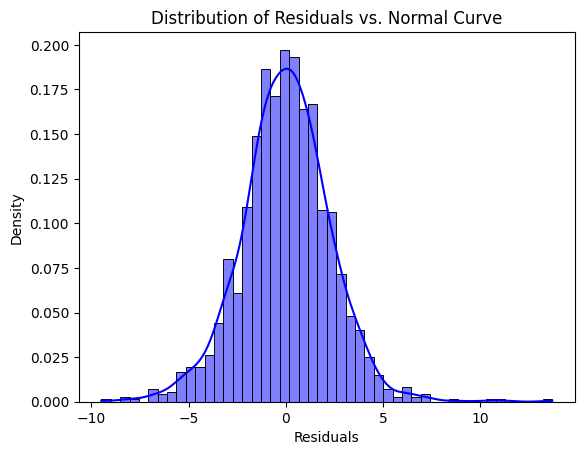

In [10]:
residuals = model_quad.resid

jb_stat, p_value = jarque_bera(residuals)

print("Jarque-Bera test:")
print(f"JB statistic = {jb_stat}")
print(f"p-value = {p_value}")

# plot the residuals
sns.histplot(residuals, kde=True, color="blue", stat="density")
plt.title("Distribution of Residuals vs. Normal Curve")
plt.xlabel("Residuals")
plt.show()

# 2.l ML estimation

In [11]:
def neg_log_likelihood(params, y, x1):
    beta0, beta1, beta2, sigma, nu = params

    if sigma <= 0 or nu <= 2:
        return 1e10

    y_pred = beta0 + beta1 * x1 + beta2 * (x1**2)

    u = y - y_pred

    log_lik = t.logpdf(u, df=nu, loc=0, scale=sigma)

    return -np.sum(log_lik)

In [12]:
y = df['Y'].values
x1 = df['X1'].values

init_params = [
    model_quad.params['const'],
    model_quad.params['X1'],
    model_quad.params['X1_sq'],
    np.std(model_quad.resid),
    10  # we use 10 because we expect the value to be in between 5 and 15, and it has to be more than 2
]

result = minimize(
    neg_log_likelihood,
    init_params,
    args=(y, x1),
    method='L-BFGS-B'
)

params_hat = result.x

print("Estimated parameters:")
print(f"beta0 = {params_hat[0]}")
print(f"beta1 = {params_hat[1]}")
print(f"beta2 = {params_hat[2]}")
print(f"sigma = {params_hat[3]}")
print(f"nu = {params_hat[4]}")

Estimated parameters:
beta0 = 10.640454255632163
beta1 = -5.938622645384285
beta2 = 1.0003674532580156
sigma = 1.9530707308675643
nu = 7.191745646795337


# 2.m JB test (ML)

In [13]:
# Extract ML parameters
b0_ml = params_hat[0]
b1_ml = params_hat[1]
b2_ml = params_hat[2]
sigma_ml = params_hat[3]
nu_ml = params_hat[4]

# Compute ML residuals using the ML betas
resid_ml = y - (b0_ml + b1_ml*x1 + b2_ml*(x1**2))

# Get the Student-t CDF values
F_u = stats.t.cdf(resid_ml, df=nu_ml, loc=0, scale=sigma_ml)

# Transform to standard normal using the inverse CDF (Phi^-1)
z_hat = stats.norm.ppf(F_u)

# JB test on z_hat
jb_stat_z, jb_pval_z = stats.jarque_bera(z_hat)

# print the results
print(f"JB Statistic: {jb_stat_z:.4f}")
print(f"p-value: {jb_pval_z:.4f}")

JB Statistic: 0.0137
p-value: 0.9932


# 2.n & 2.o  Comparison table for OLS and ML estimates and std errors

In [14]:
from statsmodels.tools.numdiff import approx_hess

# Get OLS estimates and standard errors from model 4
b_ols = model_quad.params
se_ols = model_quad.bse

# Wrapper function for the numerical differentiator
def nll_wrapper(params):
    return neg_log_likelihood(params, y, x1)

# Calculate Information matrix (Hessian of the negative log-likelihood)
info_matrix = approx_hess(result.x, nll_wrapper)

# Take inverse to get the variance-covariance matrix
cov_matrix = np.linalg.inv(info_matrix)

# The SEs of ML are the square roots of the diagonal
se_ml = np.sqrt(np.diag(cov_matrix))

# print the comparison
print(f"{'':<10} | {'OLS Estimate':<15} | {'ML Estimate':<15} || {'OLS Std Error':<15} | {'ML Std Error':<15}")
print("-" * 80)
print(f"{'Beta_0':<10} | {b_ols[0]:<15.4f} | {b0_ml:<15.4f} || {se_ols[0]:<15.4f} | {se_ml[0]:<15.4f}")
print(f"{'Beta_1':<10} | {b_ols[1]:<15.4f} | {b1_ml:<15.4f} || {se_ols[1]:<15.4f} | {se_ml[1]:<15.4f}")
print(f"{'Beta_2':<10} | {b_ols[2]:<15.4f} | {b2_ml:<15.4f} || {se_ols[2]:<15.4f} | {se_ml[2]:<15.4f}")

           | OLS Estimate    | ML Estimate     || OLS Std Error   | ML Std Error   
--------------------------------------------------------------------------------
Beta_0     | 10.5248         | 10.6405         || 0.1818          | 0.1735         
Beta_1     | -5.8906         | -5.9386         || 0.0824          | 0.0787         
Beta_2     | 0.9965          | 1.0004          || 0.0079          | 0.0075         


/tmp/ipykernel_731/2908237678.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{'Beta_0':<10} | {b_ols[0]:<15.4f} | {b0_ml:<15.4f} || {se_ols[0]:<15.4f} | {se_ml[0]:<15.4f}")
/tmp/ipykernel_731/2908237678.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{'Beta_1':<10} | {b_ols[1]:<15.4f} | {b1_ml:<15.4f} || {se_ols[1]:<15.4f} | {se_ml[1]:<15.4f}")
/tmp/ipykernel_731/2908237678.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

# 2.p ML estimation model 3

In [15]:
def neg_log_likelihood_wrong(params, y, x1):
    beta0, beta1, sigma, nu = params

    if sigma <= 0 or nu <= 2:
        return 1e10

    # WRONG predictions (missing x1**2)
    y_pred = beta0 + beta1 * x1
    u = y - y_pred

    log_lik = stats.t.logpdf(u, df=nu, loc=0, scale=sigma)

    return -np.sum(log_lik)

# Setup initial guesses (from linear OLS (model 3) estimates)
init_params_w = [
    model.params.iloc[0], # beta0
    model.params.iloc[1], # beta1
    np.std(model.resid), # sigma
    10 # nu
]

# Run the minimizer
result_wrong = minimize(
    neg_log_likelihood_wrong,
    init_params_w,
    args=(y, x1),
    method='L-BFGS-B',
    options={'maxiter': 30000} # many iterations
)

params_w = result_wrong.x

print("Estimated parameters for misspecified model:")
print(f"beta0 = {params_w[0]:.4f}")
print(f"beta1 = {params_w[1]:.4f}")
print(f"sigma = {params_w[2]:.4f}")
print(f"nu    = {params_w[3]:.4f}")

# PIT & Jarque-Bera
b0_w = params_w[0]
b1_w = params_w[1]
sigma_w = params_w[2]
nu_w = params_w[3]

resid_w = y - (b0_w + b1_w * x1)
F_u_w = stats.t.cdf(resid_w, df=nu_w, loc=0, scale=sigma_w)
z_hat_w = stats.norm.ppf(F_u_w)

jb_stat_w, jb_pval_w = stats.jarque_bera(z_hat_w)

print("\nJarque-Bera Test:")
print(f"JB Statistic: {jb_stat_w:.4f}")
print(f"p-value: {jb_pval_w:.4f}")

Estimated parameters for misspecified model:
beta0 = -6.5374
beta1 = 4.1797
sigma = 7.8269
nu    = 208.5636

Jarque-Bera Test:
JB Statistic: 108.6554
p-value: 0.0000
